# Merge the .csv files with European Capital and cities with >100k population

Merge the `cities/development/european_capitals.csv` created previously and the `cities/development/european_100000pop.csv` created with `extract_data_from_un_source.ipynb` and `check_polygons.ipynb`.

## Setup

In [1]:
%run -i "functions.py"
import contextily as cx

## Load cities

In [2]:
capitals = pd.read_csv(
    "../cities/development/european_capitals.csv",
    sep = ";"
)

cities_100000pop = pd.read_csv(
    "../cities/development/european_100000pop.csv",
    sep = ";"
)

## Retrieve population and country_code code for european capitals

In [3]:
un_list = pd.read_csv(
    "../cities/development/world_100000pop.csv",
    sep = ";"
).query("continent == 'Europe'").query("is_capital == True")
un_list.at[3566, 'city'] = "Warsaw"
un_list.at[3579, 'city'] = "Bucharest"
un_list.at[3499, 'city'] = "Luxembourg"
un_list.at[3836, 'city'] = "Bern"
un_list.at[3254, 'city'] = "Vienna"
un_list.at[3447, 'city'] = "Reykjavík"
un_list.at[3293, 'city'] = "Prague"
un_list.at[3431, 'city'] = "Athens"
un_list.at[3298, 'city'] = "Copenhagen"
un_list.at[3753, 'city'] = "Belgrade"
un_list.at[3575, 'city'] = "Lisbon"
un_list.at[3482, 'city'] = "Rome"
un_list.at[3272, 'city'] = "Brussels"
un_list

,continent,country,city,is_capital,population
3248,Europe,Albania,Tirana,True,418495
3254,Europe,Austria,Vienna,True,1897491
3262,Europe,Belarus,Minsk,True,2020133
3272,Europe,Belgium,Brussels,True,174383
3281,Europe,Bulgaria,Sofia,True,1221785
3287,Europe,Croatia,Zagreb,True,790017
3293,Europe,Czechia,Prague,True,1301432
3298,Europe,Denmark,Copenhagen,True,638790
3301,Europe,Estonia,Tallinn,True,437817
3303,Europe,Finland,Helsinki,True,656920


In [4]:
print(set(un_list['city']) - set(capitals['name_en'])) # Just Moscow

{'Moskva'}


In [5]:
capitals["country_code"] = capitals["country_en"].map(get_alpha2)
capitals

,name_en,country_en,nominatim_query,country_code
0,Amsterdam,Netherlands,"Amsterdam, North Holland",NL
1,Andorra la Vella,Andorra,Andorra la Vella,AD
2,Athens,Greece,Municipality of Athens,GR
3,Belgrade,Serbia,Belgrade,RS
4,Berlin,Germany,Berlin,DE
5,Bern,Switzerland,Bern,CH
6,Bratislava,Slovakia,Bratislava,SK
7,Brussels,Belgium,Brussels,BE
8,Bucharest,Romania,Bucharest,RO
9,Budapest,Hungary,Budapest,HU


In [6]:
capitals_with_pop = capitals.merge(
    un_list[['city', 'population']],
    left_on = 'name_en',
    right_on = 'city',
    how = 'left'
).drop(columns = ['city'])
capitals_with_pop

,name_en,country_en,nominatim_query,country_code,population
0,Amsterdam,Netherlands,"Amsterdam, North Holland",NL,821752.0
1,Andorra la Vella,Andorra,Andorra la Vella,AD,NaN
2,Athens,Greece,Municipality of Athens,GR,664046.0
3,Belgrade,Serbia,Belgrade,RS,1382045.0
4,Berlin,Germany,Berlin,DE,3644826.0
5,Bern,Switzerland,Bern,CH,134290.0
6,Bratislava,Slovakia,Bratislava,SK,435296.0
7,Brussels,Belgium,Brussels,BE,174383.0
8,Bucharest,Romania,Bucharest,RO,1722865.0
9,Budapest,Hungary,Budapest,HU,1737026.0


In [7]:
capitals_with_pop.at[1, 'population'] = 22205   # From https://unstats.un.org/unsd/demographic-social/products/dyb/documents/DYB2022/table08.pdf
capitals_with_pop.at[25, 'population'] = 161751 # From https://en.wikipedia.org/wiki/List_of_towns_and_cities_with_100,000_or_more_inhabitants
capitals_with_pop.at[29, 'population'] = 348363 # From https://en.wikipedia.org/wiki/List_of_towns_and_cities_with_100,000_or_more_inhabitants
capitals_with_pop

,name_en,country_en,nominatim_query,country_code,population
0,Amsterdam,Netherlands,"Amsterdam, North Holland",NL,821752.0
1,Andorra la Vella,Andorra,Andorra la Vella,AD,22205.0
2,Athens,Greece,Municipality of Athens,GR,664046.0
3,Belgrade,Serbia,Belgrade,RS,1382045.0
4,Berlin,Germany,Berlin,DE,3644826.0
5,Bern,Switzerland,Bern,CH,134290.0
6,Bratislava,Slovakia,Bratislava,SK,435296.0
7,Brussels,Belgium,Brussels,BE,174383.0
8,Bucharest,Romania,Bucharest,RO,1722865.0
9,Budapest,Hungary,Budapest,HU,1737026.0


## Merge capitals qith non-capitals with over 100k population

In [8]:
capitalsand100000pop = pd.concat(
    [capitals_with_pop, cities_100000pop]
).sort_values(by = 'name_en')
capitalsand100000pop

,name_en,country_en,nominatim_query,country_code,population
0,Aachen,Germany,Aachen,DE,247380.0
1,Aalborg,Denmark,NaN,DK,219476.0
2,Aarhus,Denmark,NaN,DK,352315.0
3,Aix-En-Provence,France,Aix-En-Provence,FR,142668.0
4,Alcalá De Henares,Spain,Alcalá De Henares,ES,195570.0
...,...,...,...,...,...
359,Zielona Góra,Poland,Zielona Góra,PL,141631.0
360,Zoetermeer,Netherlands,Zoetermeer,NL,124025.0
361,Zurich,Switzerland,Zurich,CH,423193.0
362,Zwolle,Netherlands,Zwolle,NL,123861.0


In [9]:
capitalsand100000pop.to_csv(
    "../cities/european_capitalsand100000pop.csv",
    sep = ";",
    index = False
)

## Save .geojson files

In [4]:
capitalsand100000pop = pd.read_csv(
    "../cities/european_capitalsand100000pop.csv",
    sep = ";"
)

In [15]:
# Save clean .geojson file (only the biggest polygon)
for id, city in tqdm(capitalsand100000pop.iterrows(), total=len(capitalsand100000pop), desc="Processing Cities"):
    filename = slugify(city['name_en']) + "_" + slugify(city['country_code'])
    geocode_cached("../cache/nominatim/", filename, city['nominatim_query'], save_polygon=True, save_path = "../cities/boundaries/", check_cache = False)

Processing Cities: 100%|██████████| 399/399 [00:08<00:00, 44.56it/s]


Processing Cities:   0%|          | 0/399 [00:00<?, ?it/s]

Processing Cities:  13%|█▎        | 53/399 [00:44<04:27,  1.29it/s]

❌ Failed on Breda (breda_nl): Tile URL resulted in a 404 error. Double-check your tile url:
https://tile.openstreetmap.org/13/4202/2723.png


Processing Cities:  45%|████▌     | 181/399 [02:40<02:58,  1.22it/s]

❌ Failed on Lausanne (lausanne_ch): Tile URL resulted in a 404 error. Double-check your tile url:
https://tile.openstreetmap.org/13/4245/2897.png


Processing Cities:  62%|██████▏   | 247/399 [03:43<02:12,  1.15it/s]

❌ Failed on Nijmegen (nijmegen_nl): Tile URL resulted in a 404 error. Double-check your tile url:
https://tile.openstreetmap.org/13/4227/2712.png


Processing Cities: 100%|██████████| 399/399 [07:23<00:00,  1.11s/it]


Completed with errors. 3 cities failed:
 - Breda: Tile URL resulted in a 404 error. Double-check your tile url:
https://tile.openstreetmap.org/13/4202/2723.png
 - Lausanne: Tile URL resulted in a 404 error. Double-check your tile url:
https://tile.openstreetmap.org/13/4245/2897.png
 - Nijmegen: Tile URL resulted in a 404 error. Double-check your tile url:
https://tile.openstreetmap.org/13/4227/2712.png


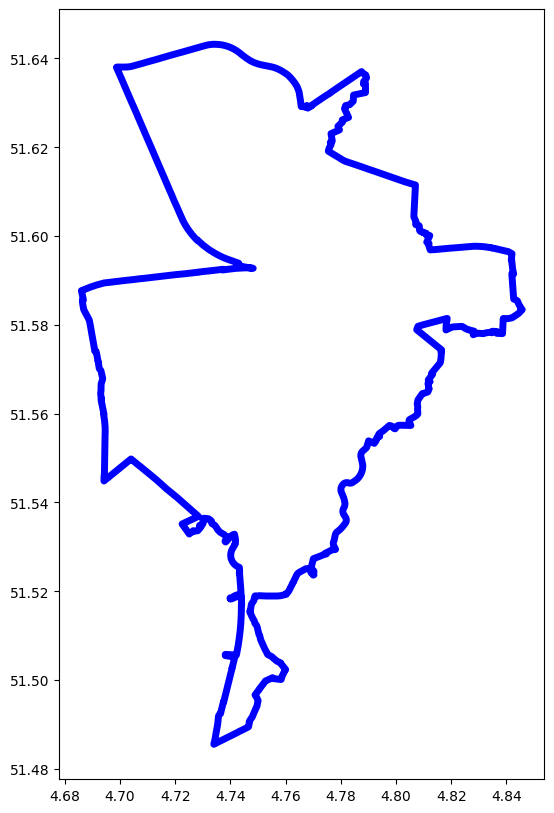

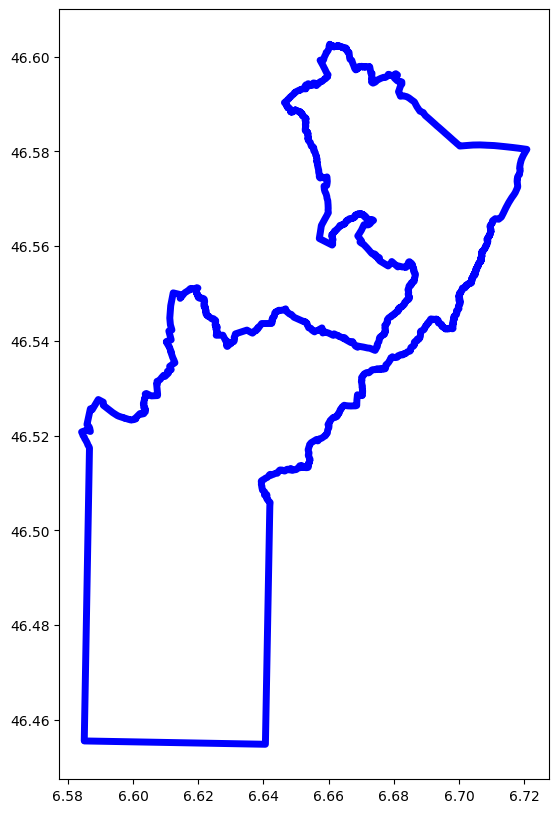

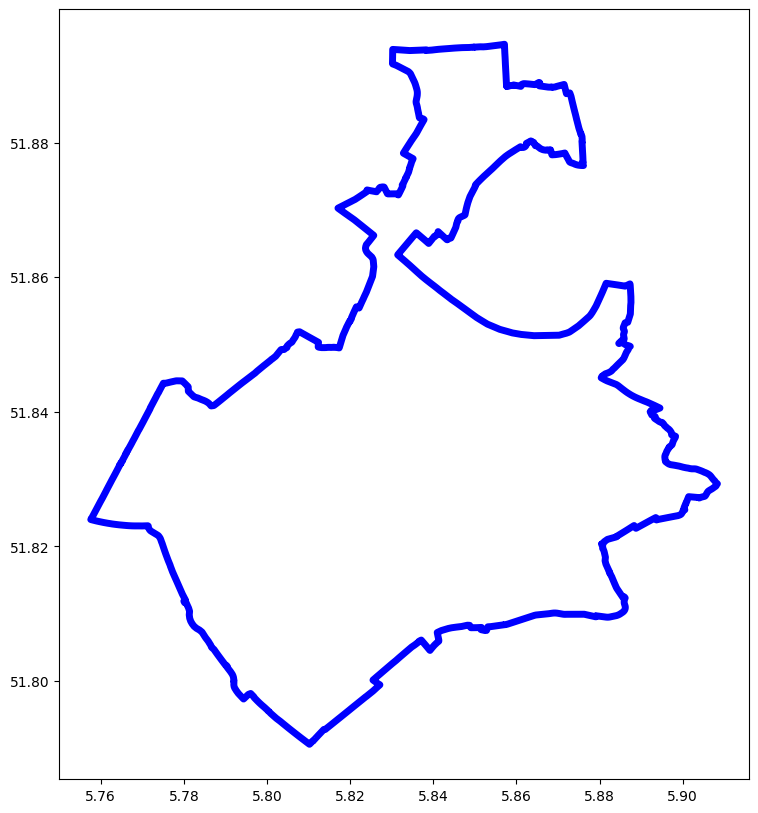

In [27]:
failed_cities = []

for id, city in tqdm(capitalsand100000pop.iterrows(), total=len(capitalsand100000pop), desc="Processing Cities"):
    city_name = city['name_en']
    filename = slugify(city['name_en']) + "_" + slugify(city['country_code'])

    try:
        if not pd.isna(city['nominatim_query']):
            gdf = gpd.read_file("../cities/boundaries/" + filename + ".geojson")
        else:
            gdf = gpd.read_file("../cities/"+slugify(city['name_en'])+".shp")

        if gdf.crs is None:
            gdf = gdf.set_crs(epsg=4326)
        
        fig, ax = plt.subplots(figsize=(10, 10))
        gdf.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=5)
        cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, crs = gdf.crs)
        plt.savefig("../plots/" + filename + ".png", dpi = 300)
        plt.close(fig)
    except Exception as e:
        tqdm.write(f"❌ Failed on {city_name} ({filename}): {e}")
        failed_cities.append({'id': id, 'city': city_name, 'error': str(e)})

if failed_cities:
    print(f"\nCompleted with errors. {len(failed_cities)} cities failed:")
    for item in failed_cities:
        print(f" - {item['city']}: {item['error']}")
else:
    print("\nAll cities processed successfully!")